In [ ]:
# IMPORT ALL NECESSARY LIBRARIES
import os
import subprocess
import zipfile
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import files

# FORCE SETUP KAGGLE & PERMISSIONS
if not os.path.exists('/root/.kaggle/kaggle.json'):     # check if kaggle.json exists in directory structure
    if not os.path.exists('kaggle.json'):
        print("Upload kaggle.json now:")
        uploaded = files.upload()                       # if not, upload kaggle.json



# Create the Kaggle config directory if it doesn't already exist
# '/root/.kaggle' is the default location where Kaggle expects API credentials
os.makedirs('/root/.kaggle', exist_ok=True)

# Copy your kaggle.json file (API key) into that directory
# This file contains your Kaggle username + API token
os.system('cp kaggle.json /root/.kaggle/')

# Set file permissions to be secure (read/write only for the owner)
# Kaggle requires this for authentication to work
os.system('chmod 600 /root/.kaggle/kaggle.json')


Upload kaggle.json now:


Saving kaggle.json to kaggle.json


0

In [ ]:
# DOWNLOAD DATASET
print("Downloading dataset...")
try:
    subprocess.run(["kaggle", "datasets", "download", "-d", "tongpython/cat-and-dog"], check=True)
except:
    subprocess.run(["kaggle", "datasets", "download", "-d", "karakuzum/dogs-vs-cats"], check=True)

# UNZIP
zip_file = [f for f in os.listdir() if f.endswith('.zip')][0]
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('data')

# FOLDER PATH SETUP
train_dir = 'data/training_set/training_set'
test_dir = 'data/test_set/test_set'

# DATA GENERATORS AND PREPROCESSING
train_datagen = ImageDataGenerator(
    # YOUR CODE HERE
    # Hint: Rescale, Rotate & Flip
)

# Only rescaling, no augmentation (we want real, untouched evaluation)
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Load training data from directory
train_gen = train_datagen.flow_from_directory(
    train_dir,             # Path to training dataset (organized in class folders)
    # YOUR CODE HERE
    # Hint: Target image size, No.of images in each batch & Type of labels
)

# Load validation/test data
val_gen = test_datagen.flow_from_directory(
    test_dir,              # Path to validation/test dataset
    target_size=(150,150), # Same size as training (VERY IMPORTANT)
    batch_size=32,
    class_mode='binary',   # Binary classification
    shuffle=False          # DO NOT shuffle → keeps order consistent for evaluation metrics
)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [ ]:
# TRANSFER LEARNING MODEL
import tensorflow as tf
from tensorflow.keras import layers, models

# Load a pre-trained model (MobileNetV2 trained on ImageNet)
# include_top=False → removes the original classification layer so we can add our own (cat vs dog)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),  # Input image size
    include_top=False,          # Exclude final dense layers
    weights='imagenet'          # Use pre-trained weights
)

# YOUR CODE HERE
# Should we let the base model's weights update during training?


# Build custom classification head
model = models.Sequential([
    base_model,                           # Feature extractor
    layers.GlobalAveragePooling2D(),      # Converts feature maps → vector
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Binary output (cat vs dog)
])

# Compile the model
model.compile(
    # YOUR CODE HERE
    # Hint: Optimizer, Loss Function, Metrics: Eg-accuracy
)

# Train the model
print("\nTraining Transfer Learning model (Epochs reduced for speed)...")
model.fit(
    train_gen,                         # Training data
    epochs=5,                          # Number of passes over dataset
    validation_data=val_gen            # Validation data for evaluation
)

/tmp/ipykernel_2320/4060870776.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Training Transfer Learning model (Epochs reduced for speed)...
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 106s 347ms/step - accuracy: 0.9277 - loss: 0.2013 - val_accuracy: 0.9595 - val_loss: 0.1011
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 55s 219ms/step - accuracy: 0.9477 - loss: 0.1327 - val_accuracy: 0.9624 - val_loss: 0.0942
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 56s 221ms/step - accuracy: 0.9500 - loss: 0.1303 - val_accuracy: 0.9654 - val_loss: 0.0938
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 231ms/step - accuracy: 0.9550 - loss: 0.1091 - val_accuracy: 0.9585 - val_loss: 0.1067
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 55s 221ms/step - accuracy: 0.9580 - loss: 0.1042 - val_accuracy: 0.9634 - val_loss: 0.1021


In [ ]:
# Save as .keras for the Streamlit app
model.save('cat_dog_classifier.keras')
print("\nModel saved as cat_dog_classifier.keras")


Model saved as cat_dog_classifier.keras



Evaluating on test set...
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step

FINAL EVALUATION METRICS
              precision    recall  f1-score   support

        cats       0.98      0.95      0.96      1011
        dogs       0.95      0.98      0.96      1012

    accuracy                           0.96      2023
   macro avg       0.96      0.96      0.96      2023
weighted avg       0.96      0.96      0.96      2023



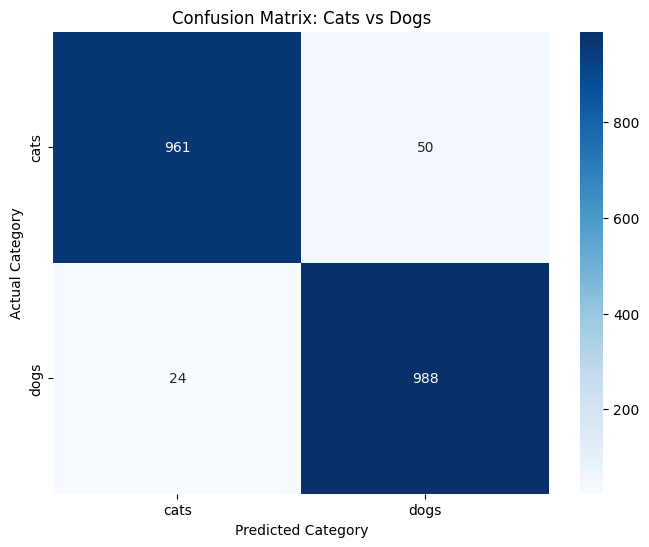


ROC-AUC Score: 0.9946


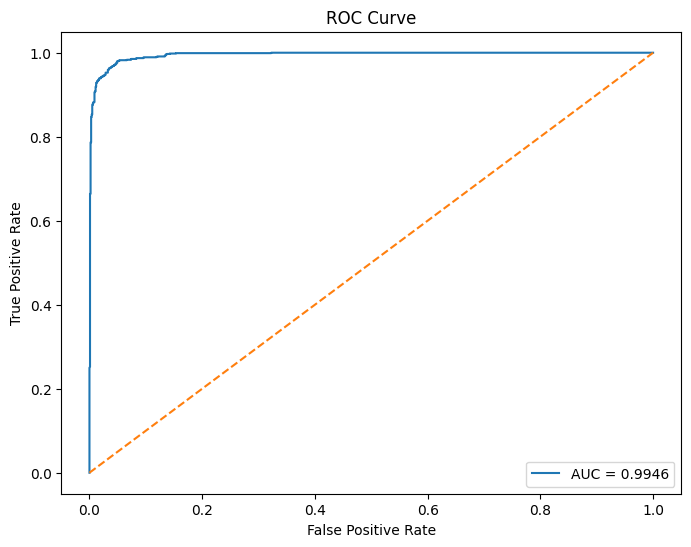


Overall Test Accuracy: 96.34%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# PREPARE TEST DATA
val_gen.reset()  # Ensure we start from the beginning
print("\nEvaluating on test set...")

# GET PREDICTIONS
predictions = model.predict(val_gen, verbose=1)

# Convert probabilities to binary classes (0 or 1)
# YOUR CODE HERE


# Get the true labels from the generator
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# PRINT CLASSIFICATION REPORT
# Gives you Precision, Recall, and F1-Score for both Cats and Dogs
print("\n" + "="*30)
print("FINAL EVALUATION METRICS")
print("="*30)
print(classification_report(y_true, y_pred, target_names=class_labels))

# PLOT CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix: Cats vs Dogs')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

# PLOT ROC-AUC CURVE
roc_auc = roc_auc_score(y_true, predictions)           # Compute ROC-AUC using true labels and predicted probabilities
print(f"\nROC-AUC Score: {roc_auc:.4f}")
fpr, tpr, _ = roc_curve(y_true, predictions)           # Get False Positive Rate and True Positive Rate for different thresholds

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Final accuracy check
loss, acc = model.evaluate(val_gen, verbose=0)
print(f"\nOverall Test Accuracy: {acc*100:.2f}%")

Upload an image of a cat or a dog:


Saving dog2.jpg to dog2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


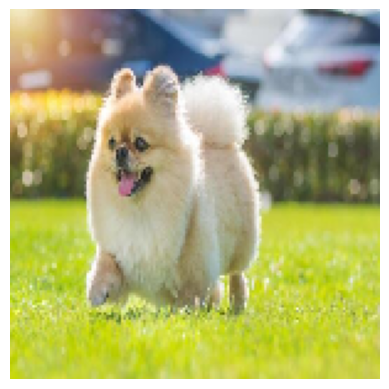

Prediction: DOG (99.86% confidence)


In [ ]:

# MODEL LOADING AND TESTING WITH USER INPUT
model = load_model('cat_dog_classifier.keras')

# Upload an image
print("Upload an image of a cat or a dog:")
uploaded = files.upload()

for fn in uploaded.keys():
    # Preprocessing the image to match model input
    path = '/content/' + fn
    # Load the image, resize, convert to array,
    # add a batch dimension, and normalize to [0,1]
    # YOUR CODE HERE
    # Hint: image.load_img → img_to_array → expand_dims → divide by 255(WHY?-See train_datagen function)

    # Prediction
    classes = model.predict(x)

    # Output Result
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # In binary classification, 0 is usually 'Cat' and 1 is 'Dog' (based on alphabetical folder order)
    if classes[0] > 0.5:
        print(f"Prediction: DOG ({classes[0][0]*100:.2f}% confidence)")
    else:
        print(f"Prediction: CAT ({(1-classes[0][0])*100:.2f}% confidence)")

In [ ]:
# Save the class indices so your Streamlit app (knows if 0 is 'cat' or 'dog' without hardcoding)
import json
with open('class_indices.json', 'w') as f:
    json.dump(val_gen.class_indices, f)